In [ ]:
!pip install nilearn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 23.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cell 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Neuroimaging specific
from nilearn import datasets, masking, input_data
from nilearn.connectome import ConnectivityMeasure
from nilearn import plotting

# Check if GPU is available
print("GPU Available:", tf.config.list_physical_devices('GPU'))


/tmp/ipython-input-438799761.py:13: FutureWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn import datasets, masking, input_data


GPU Available: []


In [ ]:
# Cell 2: Load and Process Phenotypic Data
csv1_path = "/content/drive/MyDrive/Indigo_Research/Peking_1_TestRelease_phenotypic.csv"
csv2_path = "/content/drive/MyDrive/Indigo_Research/Peking_1_phenotypic.csv"

# Load both CSVs
pheno_df1 = pd.read_csv(csv1_path)
pheno_df2 = pd.read_csv(csv2_path)

# Rename 'ID' to 'ScanDir ID' in the first dataframe
pheno_df1 = pheno_df1.rename(columns={'ID': 'ScanDir ID'})

# Merge them
pheno_df = pd.concat([pheno_df1, pheno_df2], ignore_index=True)

# Clean subject IDs
pheno_df = pheno_df.dropna(subset=['ScanDir ID'])
pheno_df['ScanDir ID'] = pheno_df['ScanDir ID'].astype(str).str.replace(r'\.0$', '', regex=True)

# For REGRESSION: Use 'ADHD Index' as target
target_column = 'ADHD Index'  # Continuous score for regression
print(f"Target variable: {target_column}")

# Replace -999 with NaN (missing values indicator in ADHD-200)
pheno_df = pheno_df.replace(-999, np.nan)

# Check missing values
print(f"\nMissing values in {target_column}: {pheno_df[target_column].isna().sum()}")
print(f"Total subjects: {len(pheno_df)}")

# Remove subjects with missing ADHD Index
pheno_df = pheno_df.dropna(subset=[target_column])
print(f"Subjects with valid ADHD Index: {len(pheno_df)}")

# Also remove subjects with missing diagnosis (for optional stratification)
pheno_df = pheno_df.dropna(subset=['DX'])
print(f"Subjects with valid diagnosis: {len(pheno_df)}")

# Check ADHD Index distribution
print(f"\nADHD Index Statistics:")
print(f"  Mean: {pheno_df[target_column].mean():.2f}")
print(f"  Std: {pheno_df[target_column].std():.2f}")
print(f"  Min: {pheno_df[target_column].min():.2f}")
print(f"  Max: {pheno_df[target_column].max():.2f}")
print(f"  Range: {pheno_df[target_column].max() - pheno_df[target_column].min():.2f}")

# Check diagnosis distribution (for stratification if desired)
print(f"\nDiagnosis distribution (DX):")
dx_counts = pheno_df['DX'].value_counts().sort_index()
for dx, count in dx_counts.items():
    dx_name = ['TDC', 'ADHD-C', 'ADHD-HI', 'ADHD-I'][int(dx)]
    print(f"  {dx_name} (Class {int(dx)}): {count} subjects")

print(f"\nSample Subject IDs: {pheno_df['ScanDir ID'].head().tolist()}")

Target variable: ADHD Index

Missing values in ADHD Index: 13
Total subjects: 136
Subjects with valid ADHD Index: 123
Subjects with valid diagnosis: 123

ADHD Index Statistics:
  Mean: 37.11
  Std: 11.70
  Min: 19.00
  Max: 68.00
  Range: 49.00

Diagnosis distribution (DX):
  TDC (Class 0): 78 subjects
  ADHD-C (Class 1): 15 subjects
  ADHD-HI (Class 2): 1 subjects
  ADHD-I (Class 3): 29 subjects

Sample Subject IDs: ['1038415', '1201251', '1245758', '1253411', '1419103']


In [ ]:
# Cell 3: Feature Extraction - Create Functional Connectomes
# Define paths and parameters
fmri_dir = "/content/drive/MyDrive/Indigo_Research/fmri_preprocessed"

# Fix: Make sure directory ends with slash
if not fmri_dir.endswith('/'):
    fmri_dir = fmri_dir + '/'

# Fix: Update deprecated import
from nilearn.maskers import NiftiLabelsMasker

atlas = datasets.fetch_atlas_schaefer_2018(n_rois=100)  # 100-region atlas
masker = NiftiLabelsMasker(labels_img=atlas.maps,
                          standardize=True,
                          memory='nilearn_cache',
                          verbose=1)

# Initialize connectivity measure
connectivity_measure = ConnectivityMeasure(kind='correlation')

# Lists to store features and labels
connectomes = []
labels = []  # Will store ADHD Index values (continuous)
subject_ids = []
failed_subjects = []

print(f"Starting feature extraction for {len(pheno_df)} subjects...")

for idx, row in pheno_df.iterrows():
    subject_id = str(row['ScanDir ID']).strip()

    # Construct file path
    fmri_path = f"{fmri_dir}sub-{subject_id}_task-rest_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz"

    # Check if file exists
    import os
    if not os.path.exists(fmri_path):
        # Try alternative pattern
        fmri_path_alt = f"{fmri_dir}{subject_id}_rest.nii.gz"
        if os.path.exists(fmri_path_alt):
            fmri_path = fmri_path_alt
        else:
            print(f"✗ File not found for subject {subject_id}")
            failed_subjects.append(subject_id)
            continue

    try:
        # Extract timeseries and compute connectome
        time_series = masker.fit_transform(fmri_path)
        connectome = connectivity_measure.fit_transform([time_series])[0]

        # Get upper triangle of correlation matrix
        mask = np.triu(np.ones(connectome.shape), k=1).astype(bool)
        features = connectome[mask]

        connectomes.append(features)
        labels.append(row[target_column])  # ADHD Index (continuous)
        subject_ids.append(subject_id)

        print(f"✓ Processed subject {subject_id} (ADHD Index: {row[target_column]:.1f})")

    except Exception as e:
        print(f"✗ Failed for subject {subject_id}: {str(e)[:100]}")
        failed_subjects.append(subject_id)
        continue

# Convert to arrays
X = np.array(connectomes)
y = np.array(labels)  # Continuous ADHD Index values

print(f"\nFeature extraction complete!")
print(f"Successfully processed: {len(connectomes)} subjects")
print(f"Failed: {len(failed_subjects)} subjects")
print(f"Final dataset shape: {X.shape}")
print(f"Number of features per subject: {X.shape[1]}")
print(f"\nADHD Index statistics in extracted data:")
print(f"  Mean: {y.mean():.2f}")
print(f"  Std: {y.std():.2f}")
print(f"  Range: [{y.min():.2f}, {y.max():.2f}]")

[fetch_atlas_schaefer_2018] Added README.md to /root/nilearn_data

[fetch_atlas_schaefer_2018] Dataset created in /root/nilearn_data/schaefer_2018

[fetch_atlas_schaefer_2018] Downloading data from 
https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/b
rain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_100Parcels_7Networks_order.txt ...

[fetch_atlas_schaefer_2018]  ...done. (0 seconds, 0 min)

[fetch_atlas_schaefer_2018] Downloading data from 
https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/b
rain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_100Parcels_7Networks_order_FSLMNI152_1mm.
nii.gz ...

...

[NiftiLabelsMasker.wrapped] Loading data from 
'/content/drive/MyDrive/Indigo_Research/fmri_preprocessed/sub-9887336_task-rest_space-MNI152NLin2009cAsym_desc-prep
roc_bold.nii.gz'

[NiftiLabelsMasker.wrapped] Extracting region signals

[NiftiLabelsMasker.wrapped] Cleaning extracted signals

_______________________________________________filter_and_extract - 5.5s, 0.1min
✓ Processed subject 9887336 (ADHD Index: 24.0)

Feature extraction complete!
Successfully processed: 123 subjects
Failed: 0 subjects
Final dataset shape: (123, 4950)
Number of features per subject: 4950

ADHD Index statistics in extracted data:
  Mean: 37.11
  Std: 11.65
  Range: [19.00, 68.00]


/tmp/ipython-input-3500639481.py:50: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  connectome = connectivity_measure.fit_transform([time_series])[0]


In [ ]:
# Cell 4: Data Preparation
# Remove subjects with missing labels
valid_indices = ~np.isnan(y)

if np.any(~valid_indices):
    print(f"Found {np.sum(~valid_indices)} subjects with NaN labels")
    X = X[valid_indices]
    y = y[valid_indices]
    subject_ids = [subject_ids[i] for i in range(len(valid_indices)) if valid_indices[i]]

print(f"Final dataset shape: {X.shape}")

# Get diagnosis for each subject
diagnoses = []
for subject_id in subject_ids:
    dx = pheno_df[pheno_df['ScanDir ID'] == subject_id]['DX'].values[0]
    diagnoses.append(dx)
diagnoses = np.array(diagnoses)

# Check class distribution
print(f"\nDiagnosis distribution in extracted data:")
unique_dx, dx_counts = np.unique(diagnoses, return_counts=True)
for dx, count in zip(unique_dx, dx_counts):
    dx_name = ['TDC', 'ADHD-C', 'ADHD-HI', 'ADHD-I'][int(dx)]
    print(f"  {dx_name} (Class {int(dx)}): {count} samples")

# Check if any class has only 1 sample (can't stratify)
if np.min(dx_counts) < 2:
    print(f"\n⚠ Warning: Some classes have < 2 samples. Cannot use stratification.")
    print("Using simple random split instead.")

    # Simple random split without stratification
    # First split: 80% train+val, 20% test
    X_temp, X_test, y_temp, y_test, ids_temp, test_ids = train_test_split(
        X, y, subject_ids, test_size=0.2, random_state=42
    )

    # Second split: 75% train, 25% val
    X_train, X_val, y_train, y_val, train_ids, val_ids = train_test_split(
        X_temp, y_temp, ids_temp, test_size=0.25, random_state=42
    )

    # Get diagnoses for each split
    dx_train = []
    dx_val = []
    dx_test = []

    for subject_id in train_ids:
        dx_train.append(pheno_df[pheno_df['ScanDir ID'] == subject_id]['DX'].values[0])
    for subject_id in val_ids:
        dx_val.append(pheno_df[pheno_df['ScanDir ID'] == subject_id]['DX'].values[0])
    for subject_id in test_ids:
        dx_test.append(pheno_df[pheno_df['ScanDir ID'] == subject_id]['DX'].values[0])

    dx_train = np.array(dx_train)
    dx_val = np.array(dx_val)
    dx_test = np.array(dx_test)

else:
    # Use stratification with diagnosis
    print(f"\nUsing diagnosis for stratification")

    # First split: 80% train+val, 20% test
    X_temp, X_test, y_temp, y_test, ids_temp, test_ids, dx_temp, dx_test = train_test_split(
        X, y, subject_ids, diagnoses,
        test_size=0.2, random_state=42, stratify=diagnoses
    )

    # Second split: 75% train, 25% val
    X_train, X_val, y_train, y_val, train_ids, val_ids, dx_train, dx_val = train_test_split(
        X_temp, y_temp, ids_temp, dx_temp,
        test_size=0.25, random_state=42, stratify=dx_temp
    )

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\nDataset splits:")
print(f"Training set: {X_train_scaled.shape} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set: {X_val_scaled.shape} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Testing set: {X_test_scaled.shape} ({len(X_test)/len(X)*100:.1f}%)")

print(f"\nADHD Index statistics:")
print(f"Train: mean={y_train.mean():.2f}, std={y_train.std():.2f}, range=[{y_train.min():.1f}, {y_train.max():.1f}]")
print(f"Val:   mean={y_val.mean():.2f}, std={y_val.std():.2f}, range=[{y_val.min():.1f}, {y_val.max():.1f}]")
print(f"Test:  mean={y_test.mean():.2f}, std={y_test.std():.2f}, range=[{y_test.min():.1f}, {y_test.max():.1f}]")

print(f"\nDiagnosis distribution in splits:")
for split_name, dx_array in [("Train", dx_train), ("Val", dx_val), ("Test", dx_test)]:
    unique, counts = np.unique(dx_array, return_counts=True)
    print(f"{split_name}: ", end="")
    for dx, count in zip(unique, counts):
        dx_name = ['TDC', 'ADHD-C', 'ADHD-HI', 'ADHD-I'][int(dx)]
        print(f"{dx_name}({count}) ", end="")
    print()

Final dataset shape: (123, 4950)

Diagnosis distribution in extracted data:
  TDC (Class 0): 78 samples
  ADHD-C (Class 1): 15 samples
  ADHD-HI (Class 2): 1 samples
  ADHD-I (Class 3): 29 samples

⚠ Warning: Some classes have < 2 samples. Cannot use stratification.
Using simple random split instead.

Dataset splits:
Training set: (73, 4950) (59.3%)
Validation set: (25, 4950) (20.3%)
Testing set: (25, 4950) (20.3%)

ADHD Index statistics:
Train: mean=36.36, std=11.65, range=[19.0, 66.0]
Val:   mean=38.64, std=12.54, range=[20.0, 68.0]
Test:  mean=37.76, std=10.48, range=[21.0, 58.0]

Diagnosis distribution in splits:
Train: TDC(46) ADHD-C(9) ADHD-I(18) 
Val: TDC(17) ADHD-C(4) ADHD-I(4) 
Test: TDC(15) ADHD-C(2) ADHD-HI(1) ADHD-I(7) 


In [ ]:
# Cell 5: Model Architecture
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)  # Single output for regression (ADHD Index prediction)
])

# Compile
model.compile(
    optimizer='adam',
    loss='mse',  # Mean Squared Error for regression
    metrics=['mae']  # Mean Absolute Error
)

# Display model architecture
model.summary()

print(f"\nModel configured:")
print(f"- Output: Single value (predicted ADHD Index)")
print(f"- Loss: Mean Squared Error (MSE)")
print(f"- Metric: Mean Absolute Error (MAE)")
print(f"- Expected ADHD Index range in data: {y_train.min():.1f} to {y_train.max():.1f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       633,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 644,097 (2.46 MB)

 Trainable params: 644,097 (2.46 MB)

 Non-trainable params: 0 (0.00 B)


Model configured for REGRESSION:
- Output: Single value (predicted ADHD Index)
- Loss: Mean Squared Error (MSE)
- Metric: Mean Absolute Error (MAE)
- Expected ADHD Index range in data: 19.0 to 66.0


In [ ]:
# Cell 6: Training
# Custom callback
class ProgressTracker(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}: "
                  f"Loss = {logs['loss']:.4f}, "
                  f"MAE = {logs['mae']:.4f}, "
                  f"Val Loss = {logs['val_loss']:.4f}, "
                  f"Val MAE = {logs['val_mae']:.4f}")

# Early stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

print("Starting training for ADHD Index prediction (regression)...")

history = model.fit(
    X_train_scaled, y_train,
    epochs=200,
    batch_size=16,
    validation_data=(X_val_scaled, y_val),
    verbose=0,
    callbacks=[ProgressTracker(), early_stopping]
)

print(f"Training completed! Stopped at epoch {len(history.history['loss'])}")

Starting training for ADHD Index prediction (regression)...
Epoch 1: Loss = 1237.2349, MAE = 33.2616, Val Loss = 965.6467, Val MAE = 27.9269
Epoch 10: Loss = 177.3922, MAE = 10.2996, Val Loss = 454.7169, Val MAE = 17.9020
Epoch 20: Loss = 63.6034, MAE = 6.2000, Val Loss = 408.6677, Val MAE = 17.9994
Epoch 30: Loss = 72.2828, MAE = 7.1915, Val Loss = 366.3111, Val MAE = 16.3901
Epoch 40: Loss = 62.3806, MAE = 6.5867, Val Loss = 412.2466, Val MAE = 17.3989
Epoch 50: Loss = 63.3870, MAE = 5.9588, Val Loss = 372.1917, Val MAE = 16.6452
Epoch 53: early stopping
Restoring model weights from the end of the best epoch: 33.
Training completed! Stopped at epoch 53


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
=== REGRESSION EVALUATION ===
Mean Absolute Error (MAE): 16.970
Mean Squared Error (MSE): 424.198
Root Mean Squared Error (RMSE): 20.596
R² Score: -2.863

Baseline (predicting mean=36.4):
  Baseline MAE: 9.276
  Baseline R²: -0.018
  Model improvement: -82.9% reduction in MAE


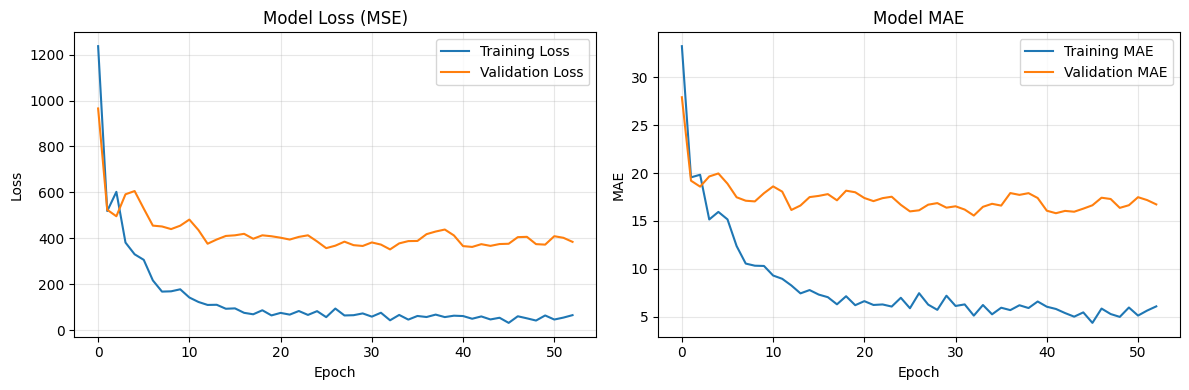

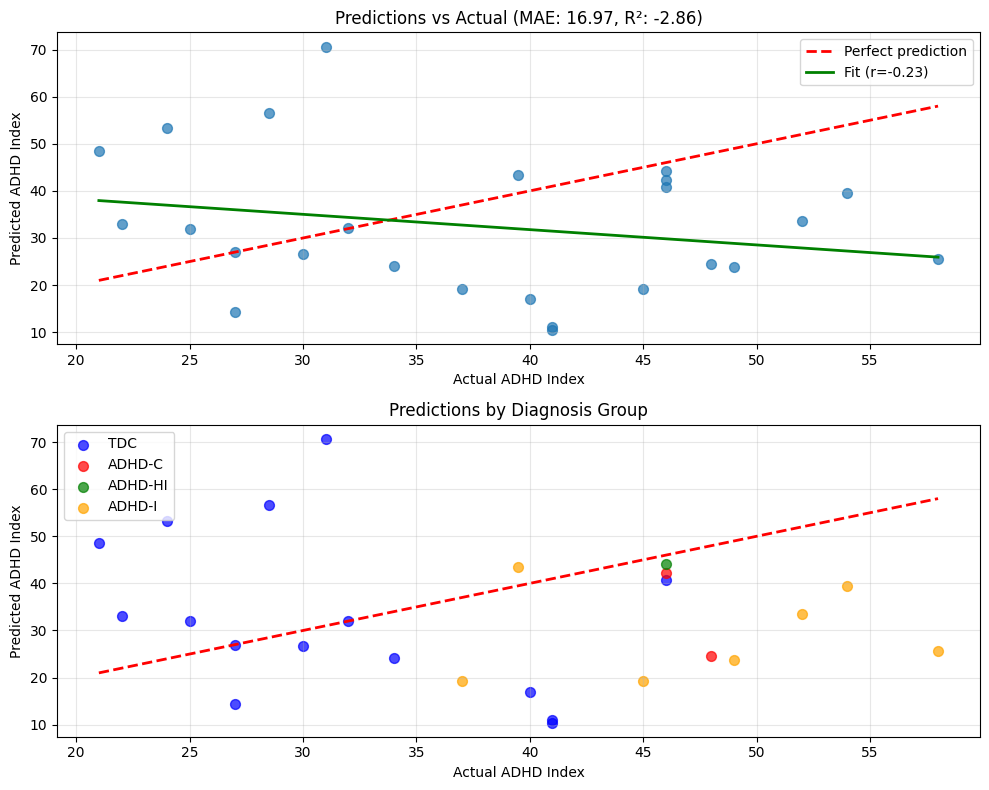

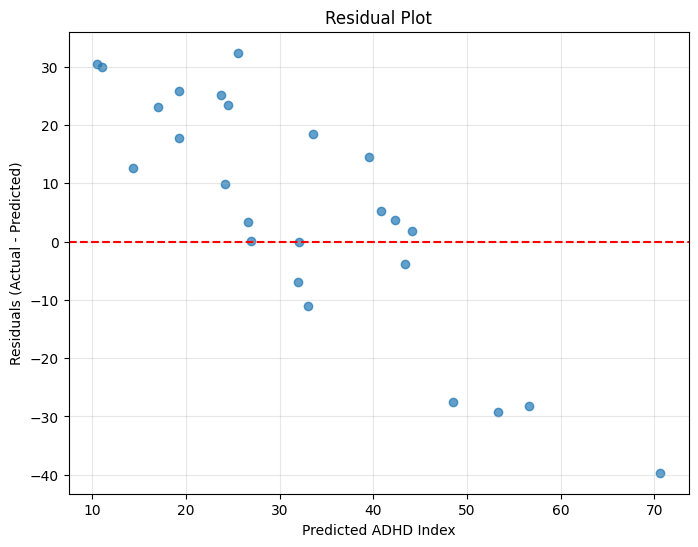

In [ ]:
# Cell 7: Evaluation
# Make predictions
y_pred = model.predict(X_test_scaled).flatten()

# Calculate regression metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=== EVALUATION ===")
print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

# Compare to baseline (predicting mean)
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)
print(f"\nBaseline (predicting mean={y_train.mean():.1f}):")
print(f"  Baseline MAE: {baseline_mae:.3f}")
print(f"  Baseline R²: {baseline_r2:.3f}")
print(f"  Model improvement: {((baseline_mae - mae)/baseline_mae*100):.1f}% reduction in MAE")

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot predictions vs actual
plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.scatter(y_test, y_pred, alpha=0.7, s=50)
# Perfect prediction line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
# Linear fit
from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(y_test, y_pred)
x_range = np.array([y_test.min(), y_test.max()])
plt.plot(x_range, slope*x_range + intercept, 'g-', lw=2, label=f'Fit (r={r_value:.2f})')

plt.xlabel('Actual ADHD Index')
plt.ylabel('Predicted ADHD Index')
plt.title(f'Predictions vs Actual (MAE: {mae:.2f}, R²: {r2:.2f})')
plt.legend()
plt.grid(True, alpha=0.3)

# Add diagnosis information with colors
plt.subplot(2, 1, 2)
colors = ['blue', 'red', 'green', 'orange']
diagnosis_names = ['TDC', 'ADHD-C', 'ADHD-HI', 'ADHD-I']

# Get diagnosis for test subjects
test_diagnoses = []
for subject_id in test_ids:
    dx = pheno_df[pheno_df['ScanDir ID'] == subject_id]['DX'].values[0]
    test_diagnoses.append(dx)

for dx in [0, 1, 2, 3]:
    indices = [i for i, d in enumerate(test_diagnoses) if d == dx]
    if indices:
        plt.scatter(np.array(y_test)[indices], np.array(y_pred)[indices],
                   color=colors[dx], alpha=0.7, s=50, label=diagnosis_names[dx])

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual ADHD Index')
plt.ylabel('Predicted ADHD Index')
plt.title('Predictions by Diagnosis Group')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Residual plot
plt.figure(figsize=(8, 6))
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted ADHD Index')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Cell 8: Save Results
# Save the trained model
model.save('/content/drive/MyDrive/Indigo_Research/results_iterations/adhd_index_predictor_model.h5')

# Create comprehensive results dataframe
results_df = pd.DataFrame({
    'Subject_ID': test_ids,
    'Diagnosis': test_diagnoses,
    'Diagnosis_Label': [diagnosis_names[int(d)] for d in test_diagnoses],
    'Actual_ADHD_Index': y_test,
    'Predicted_ADHD_Index': y_pred,
    'Error': y_test - y_pred,
    'Absolute_Error': np.abs(y_test - y_pred)
})

# Calculate performance by diagnosis group
print("\nPerformance by Diagnosis Group:")
for dx in [0, 1, 2, 3]:
    indices = results_df['Diagnosis'] == dx
    if indices.sum() > 0:
        group_mae = results_df.loc[indices, 'Absolute_Error'].mean()
        group_r2 = r2_score(results_df.loc[indices, 'Actual_ADHD_Index'],
                           results_df.loc[indices, 'Predicted_ADHD_Index'])
        print(f"{diagnosis_names[dx]}: MAE = {group_mae:.2f}, R² = {group_r2:.2f}, N = {indices.sum()}")

# Save results
results_path = '/content/drive/MyDrive/Indigo_Research/results_iterations/adhd_index_prediction_results.csv'
results_df.to_csv(results_path, index=False)

print(f"\nModel saved to: /content/drive/MyDrive/Indigo_Research?results_iterations/adhd_index_predictor_model.h5")
print(f"Results saved to: {results_path}")
print("\nSample predictions:")
print(results_df.head(10))

# Save training history for reporting
history_df = pd.DataFrame(history.history)
history_df.to_csv('/content/drive/MyDrive/Indigo_Research/results_iterations/training_history.csv', index=False)
print(f"Training history saved")


Performance by Diagnosis Group:
TDC: MAE = 17.14, R² = -7.30, N = 15
ADHD-C: MAE = 13.60, R² = -281.70, N = 2
ADHD-HI: MAE = 1.87, R² = nan, N = 1
ADHD-I: MAE = 19.72, R² = -8.11, N = 7

Model saved to: /content/drive/MyDrive/Indigo_Research/adhd_index_predictor_model.h5
Results saved to: /content/drive/MyDrive/Indigo_Research/adhd_index_prediction_results.csv

Sample predictions:
  Subject_ID  Diagnosis Diagnosis_Label  Actual_ADHD_Index  \
0    2380326          3          ADHD-I               39.5   
1    6550938          0             TDC               34.0   
2    8463326          3          ADHD-I               58.0   
3    3262042          0             TDC               31.0   
4    1419103          0             TDC               41.0   
5    3559087          2         ADHD-HI               46.0   
6    1689948          0             TDC               27.0   
7    3889095          0             TDC               28.5   
8    3124419          1          ADHD-C               46.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
